Loading csv file as dataframe

In [1]:
import pandas as pd
df = pd.read_csv('cv4e_calls_channel1_v2.csv')
df

,Selection,View,Channel,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,delta_time_s,call_type,selection_fpath,...,Model,Stage,NestAge,NestlingAge,Trial,Weather,wav_fpath,wav_fname,has_wav,has_metadata
0,1,Spectrogram 1,1,0.084678,0.779036,3664.100,22076.300,0.6944,Cheer,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,12,2.0,1,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,AZ02 Trial 1_trim.WAV,True,True
1,2,Spectrogram 1,1,1.693557,2.438721,2931.300,19877.900,0.7452,Cheer,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,12,2.0,1,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,AZ02 Trial 1_trim.WAV,True,True
2,20,Spectrogram 1,1,2.648723,2.919692,3669.600,15732.900,0.2710,A,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,12,2.0,1,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,AZ02 Trial 1_trim.WAV,True,True
3,60,Spectrogram 1,1,2.919692,3.370178,4055.700,6250.500,0.4505,Cheer,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,12,2.0,1,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,AZ02 Trial 1_trim.WAV,True,True
4,32,Spectrogram 1,1,3.610663,3.715663,1138.800,6369.100,0.1050,Check,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,12,2.0,1,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,AZ02 Trial 1_trim.WAV,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6233,14,Spectrogram 1,1,55.328363,55.463806,909.953,12549.763,0.1354,Check,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,14,3.0,3,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,SL56 Trial 3_trim.WAV,True,True
6234,20,Spectrogram 1,1,58.822345,59.440671,4132.701,20815.166,0.6183,Cheer,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,14,3.0,3,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,SL56 Trial 3_trim.WAV,True,True
6235,21,Spectrogram 1,1,62.985739,63.680620,4246.445,17251.185,0.6949,Cheer,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,14,3.0,3,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,SL56 Trial 3_trim.WAV,True,True
6236,22,Spectrogram 1,1,67.647899,68.531221,4056.872,20928.910,0.8833,Cheer,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,...,Cowbird,Nestling,14,3.0,3,clear,C:\Users\sllaw\OneDrive\Documents\OSU Postdoc\...,SL56 Trial 3_trim.WAV,True,True


In [3]:
df.columns

Index(['Selection', 'View', 'Channel', 'begin_time_s', 'end_time_s',
       'low_freq_hz', 'high_freq_hz', 'delta_time_s', 'call_type',
       'selection_fpath', 'file_id', 'channel_is_one', 'NestID', 'Site',
       'Date', 'Time', 'Model', 'Stage', 'NestAge', 'NestlingAge', 'Trial',
       'Weather', 'wav_fpath', 'wav_fname', 'has_wav', 'has_metadata'],
      dtype='object')

Count unique nest IDs

In [ ]:
df["NestID"].nunique()


40

Count number of trials

In [4]:
df["file_id"].nunique()

111

### Visualize different aspects of data frame

Nest stage by site

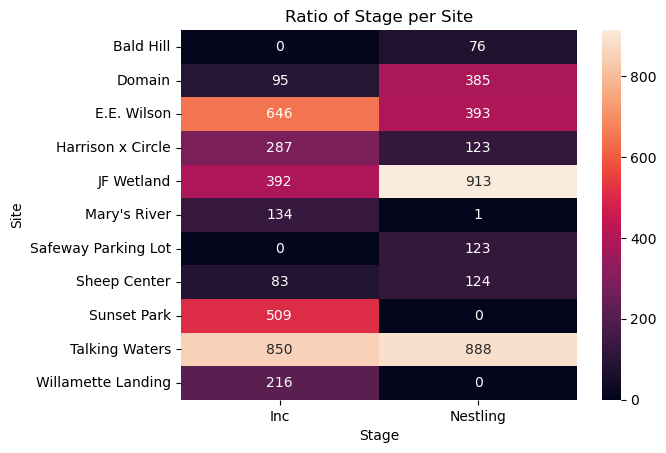

In [11]:
#plot ratio of Stage per Site from the dataframe
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pivot table for the ratio of Stage per Site
pivot_table = df.pivot_table(index='Site', columns='Stage', aggfunc='size', fill_value=0)

# Plot the ratio
sns.heatmap(pivot_table, annot=True, fmt="d")
plt.title("Ratio of Stage per Site")
plt.show()

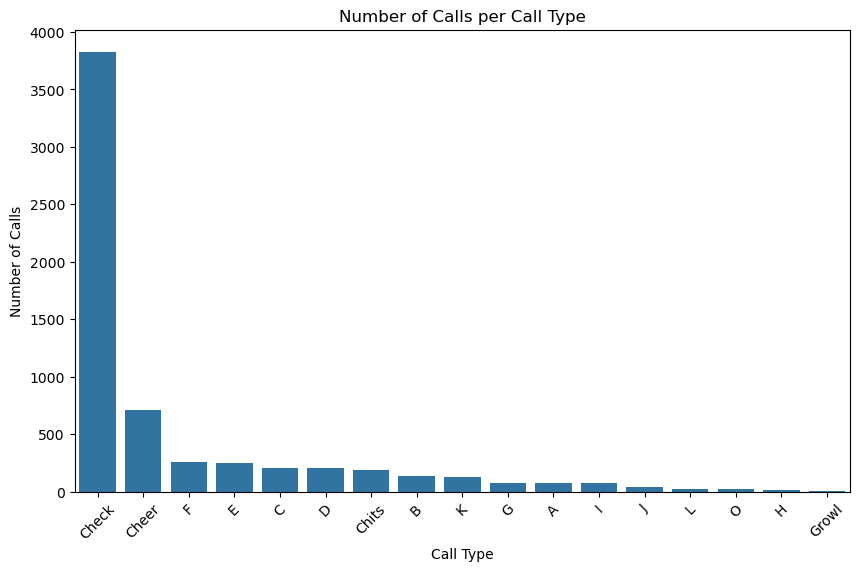

In [17]:
# plot number of calls per call_type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='call_type', order=df['call_type'].value_counts().index)
plt.title("Number of Calls per Call Type")
plt.xlabel("Call Type")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.show()

In [18]:
# Fix the call_type inconsistencies
df['call_type'] = df['call_type'].str.replace('Chits ', 'Chits')  # Remove trailing space
df['call_type'] = df['call_type'].str.replace('CheckCheck', 'Check')  # Fix double Check


print("\nUpdated call_type values:")
print(df['call_type'].value_counts())


Updated call_type values:
call_type
Check    3828
Cheer     707
F         256
E         248
C         202
D         201
Chits     191
B         136
K         130
G          77
A          76
I          75
J          39
L          26
O          24
H          14
Growl       5
Name: count, dtype: int64


In [9]:
# Save the corrected dataframe back to the CSV
df.to_csv('cv4e_calls_channel1.csv', index=False)

print("CSV file updated successfully!")

CSV file updated successfully!


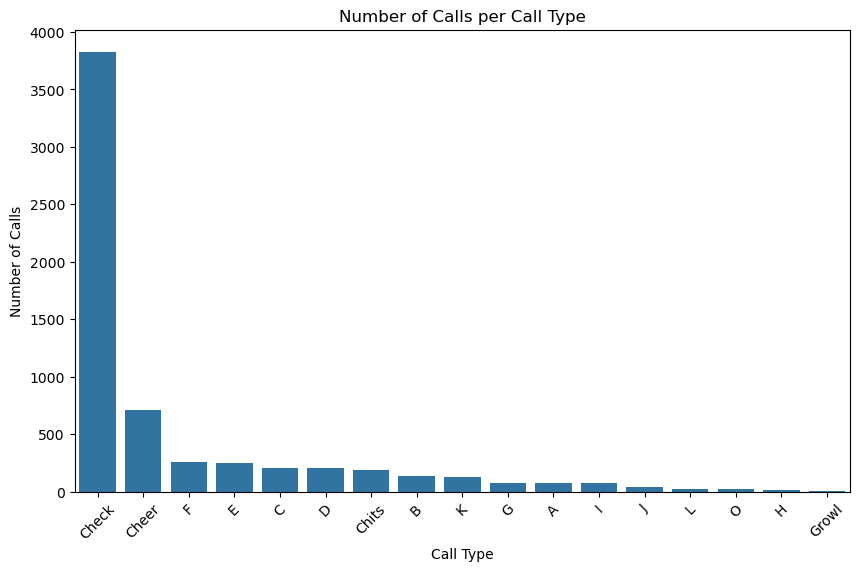

In [16]:
# plot number of calls per call_type
import pandas as pd
df = pd.read_csv('cv4e_calls_channel1_v2.csv')
df
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='call_type', order=df['call_type'].value_counts().index)
plt.title("Number of Calls per Call Type")
plt.xlabel("Call Type")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.show()

Check trials for rare call types

In [1]:
import pandas as pd

csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_louis/cv4e_calls_channel1_splitrandom.csv"
df = pd.read_csv(csv_path)

# Replace 'Cheer' with your desired call_type
call_type = 'E'
unique_file_ids = df[df['call_type'] == call_type]['file_id'].unique()
print(unique_file_ids)

['SL07_Trial_2_trim' 'SL09_Trial_3_trim' 'SL11_Trial_3_trim'
 'SL12_Trial_3_trim' 'SL13_Trial_1_trim' 'SL13_Trial_2_trim'
 'SL16_Trial_2_trim' 'SL17a_Trial_2_trim' 'SL17a_Trial_3_trim'
 'SL17b_Trial_3_trim' 'SL21_Trial_1_trim' 'SL22_Trial_3_trim'
 'SL30_Trial_2_trim' 'SL38_Trial_1_trim' 'SL42_Trial_1_trim'
 'SL42_Trial_2_trim' 'SL42_Trial_3_trim' 'SL44_Trial_1_trim'
 'SL44_Trial_2_trim' 'SL49_Trial_1_trim' 'SL50_Trial_3_trim']


Changing call N to chits after checking over data

In [9]:
import pandas as pd

csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1_v2.csv"
df = pd.read_csv(csv_path)

df.loc[df['call_type'] == 'N', 'call_type'] = 'Chits'

df.to_csv(csv_path, index=False)
print("All 'N' call_type values changed to 'Chits' and saved.")

All 'N' call_type values changed to 'Chits' and saved.


Changing call M to A after checking over data

In [ ]:
import pandas as pd

csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1_v2.csv"
df = pd.read_csv(csv_path)

df.loc[df['call_type'] == 'M', 'call_type'] = 'A'

df.to_csv(csv_path, index=False)
print("All call_type values changed and saved.")

All call_type values changed and saved.


In [24]:
import pandas as pd

csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1_v2.csv"
df = pd.read_csv(csv_path)

df.loc[df['call_type'] == 'L', 'call_type'] = 'C'

df.to_csv(csv_path, index=False)
print("All call_type values changed and saved.")

All call_type values changed and saved.
